# TSA 2026 Capstone Project
## Time Series Forecasting and Portfolio Optimization Using ARIMA

# SECTION 1 — IMPORTS

In [23]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error

from pmdarima import auto_arima

# SECTION 2 — CONFIGURATION

In [24]:
INITIAL_CAPITAL = 1000000

STOCKS = {
    'HDFCBANK.NS': 'Banking',
    'TCS.NS': 'IT',
    'SUNPHARMA.NS': 'Pharma',
    'HINDUNILVR.NS': 'FMCG',
    'MARUTI.NS': 'Auto',
    'RELIANCE.NS': 'Energy'
}

START_DATE = '2021-01-01'
END_DATE = '2025-12-31'

TRAIN_END = '2025-06-30'
TEST_START = '2025-07-01'

# SECTION 3 — DATA COLLECTION

In [ ]:
stock_data = {}

for stock in STOCKS.keys():

    try:

        df = yf.download(
            stock,
            start=START_DATE,
            end=END_DATE,
            interval='1d',
            auto_adjust=True
        )

        if df.empty:
            print(f'{stock} download failed')
            continue

        df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

        stock_data[stock] = df

        csv_name = stock.replace('.NS', '')

        df.to_csv(
            f'../data/{csv_name}.csv'
        )

        print(f'{stock} downloaded successfully')

    except Exception as e:

        print(f'Error downloading {stock}: {e}')

print('Data Download Complete')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


HDFCBANK.NS downloaded successfully
TCS.NS downloaded successfully
SUNPHARMA.NS downloaded successfully
HINDUNILVR.NS downloaded successfully
MARUTI.NS downloaded successfully


[*********************100%***********************]  1 of 1 completed

RELIANCE.NS downloaded successfully
Data Download Complete


# SECTION 4 — DATA PREPROCESSING

## Missing Value Handling

In [26]:
for stock in stock_data:
    stock_data[stock] = stock_data[stock].ffill().bfill()

## ADF Stationarity Test

In [27]:
def adf_test(series):

    result = adfuller(series.dropna())

    return {
        'ADF Statistic': result[0],
        'p-value': result[1]
    }

## Stationarity Check and Differencing

In [28]:
stationarity_results = {}

for stock, df in stock_data.items():

    result = adf_test(df['Close'])

    stationarity_results[stock] = result

    if result['p-value'] > 0.05:
        df['Close_Diff'] = df['Close'].diff()
    else:
        df['Close_Diff'] = df['Close']

## Train Test Split

In [29]:
train_data = {}
test_data = {}

for stock, df in stock_data.items():

    train_data[stock] = df.loc[:TRAIN_END]
    test_data[stock] = df.loc[TEST_START:]

# SECTION 5 — STOCK JUSTIFICATION

## Rolling Volatility

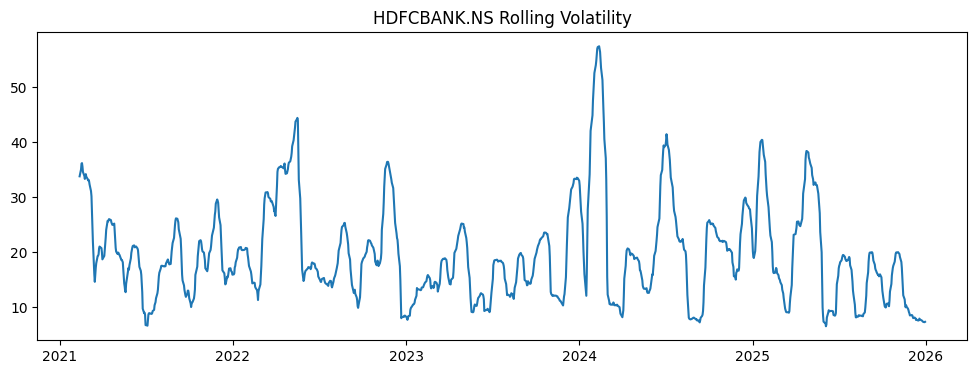

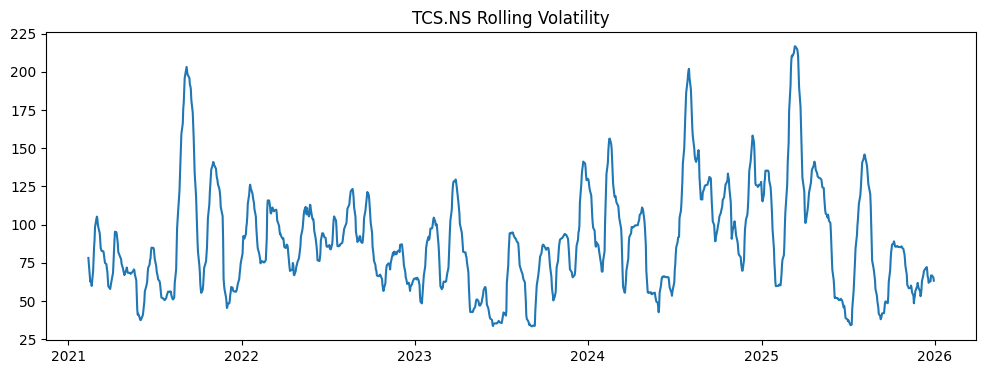

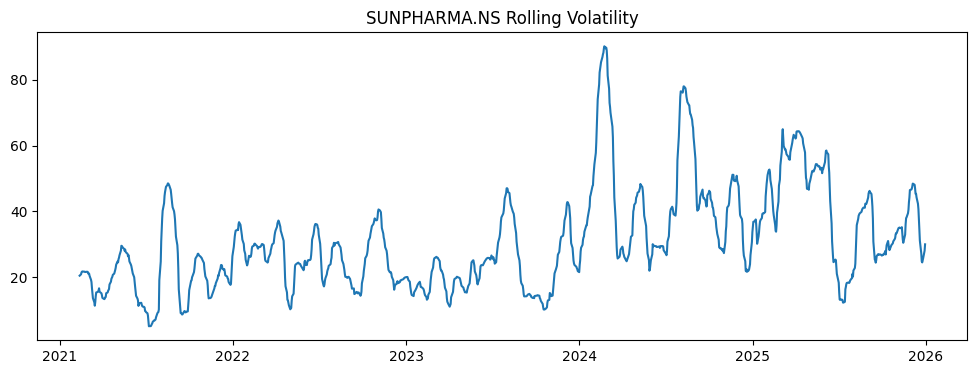

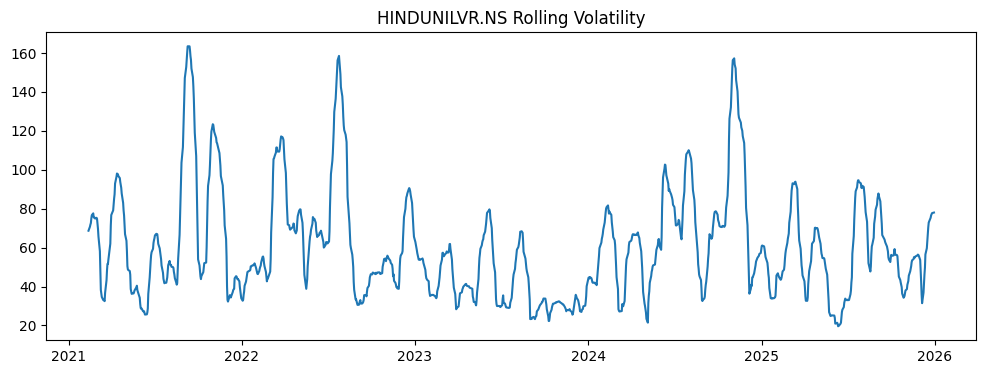

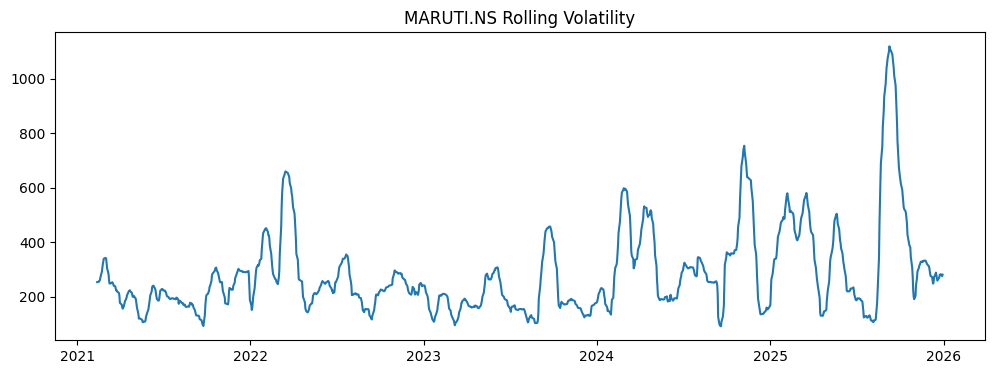

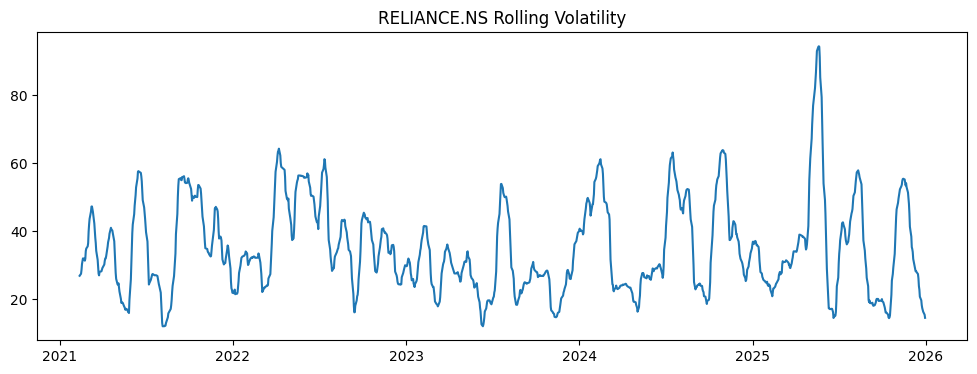

In [30]:
for stock, df in stock_data.items():

    df['Rolling_STD'] = df['Close'].rolling(30).std()

    plt.figure(figsize=(12, 4))

    plt.plot(df['Rolling_STD'])

    plt.title(f'{stock} Rolling Volatility')

    plt.show()

## STL Decomposition

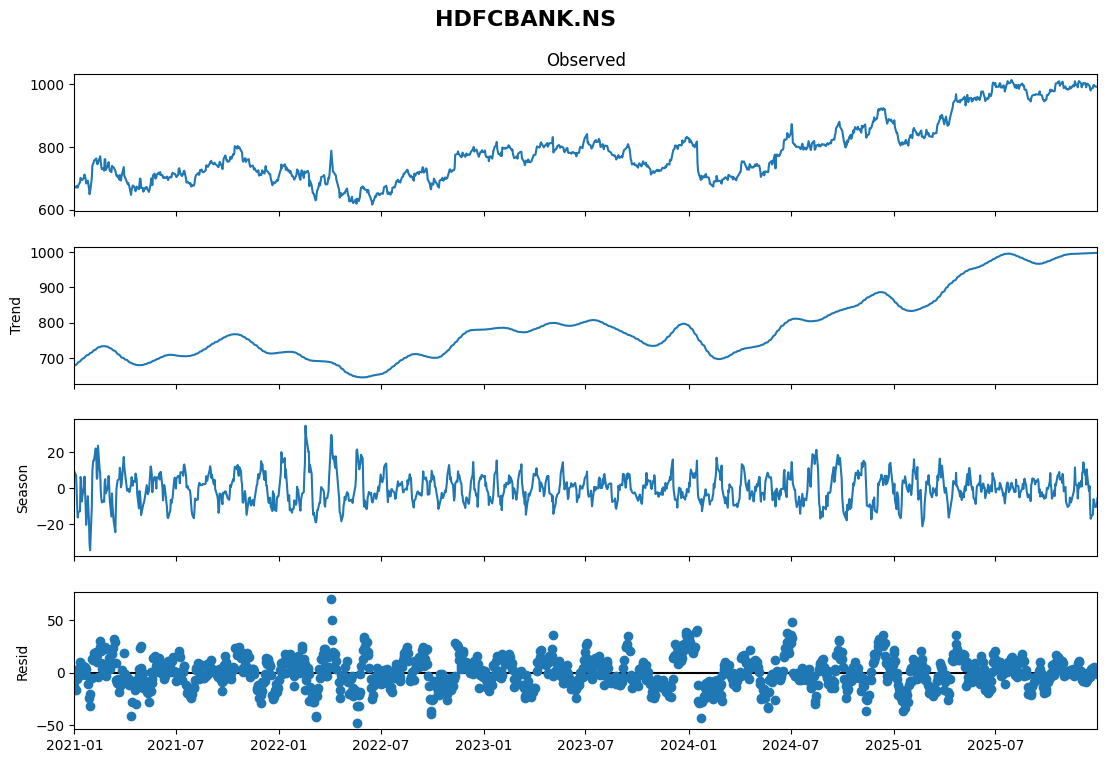

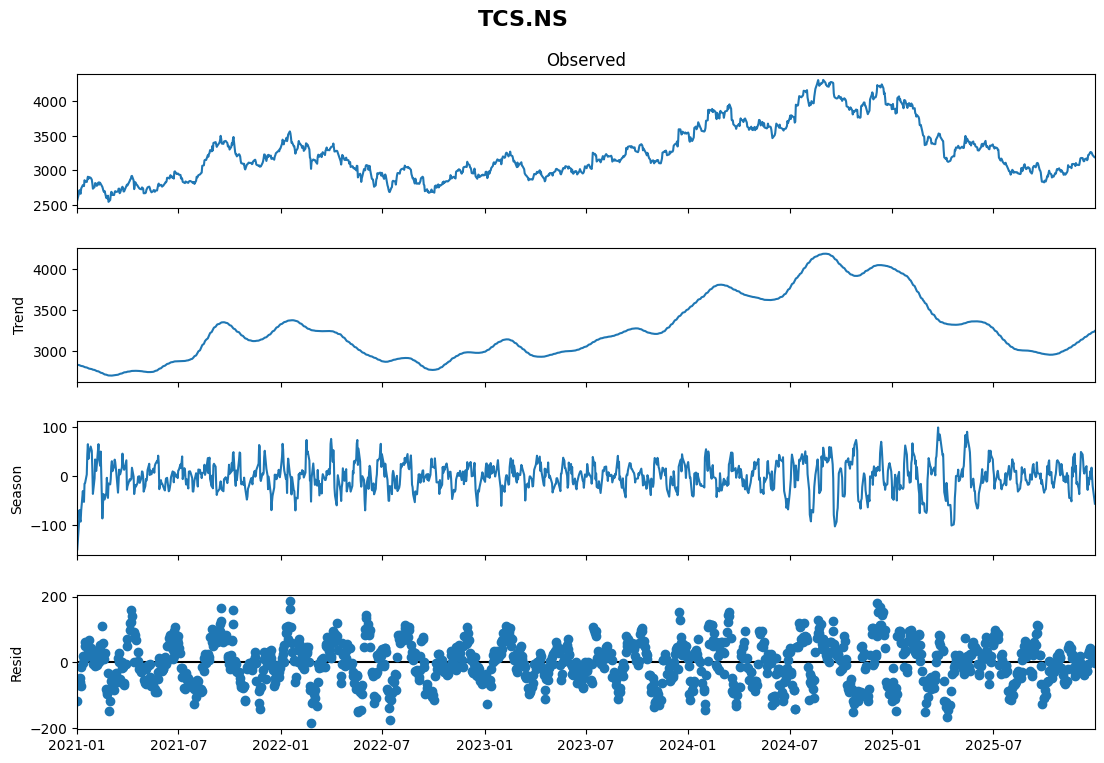

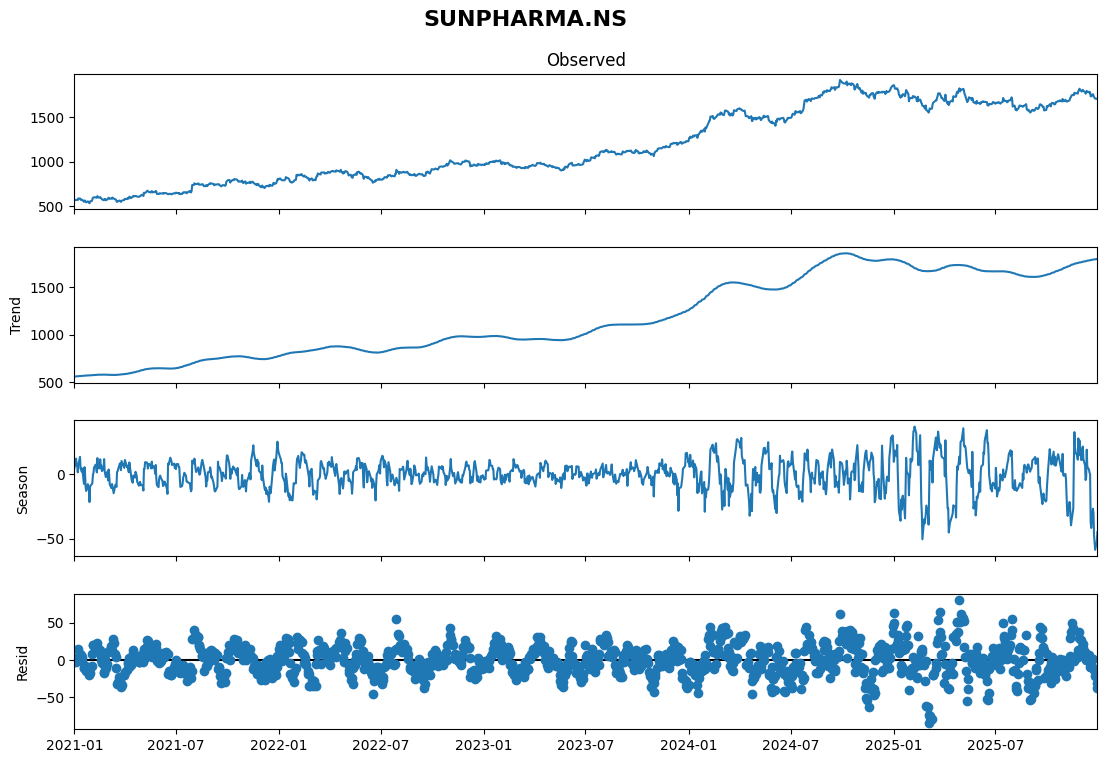

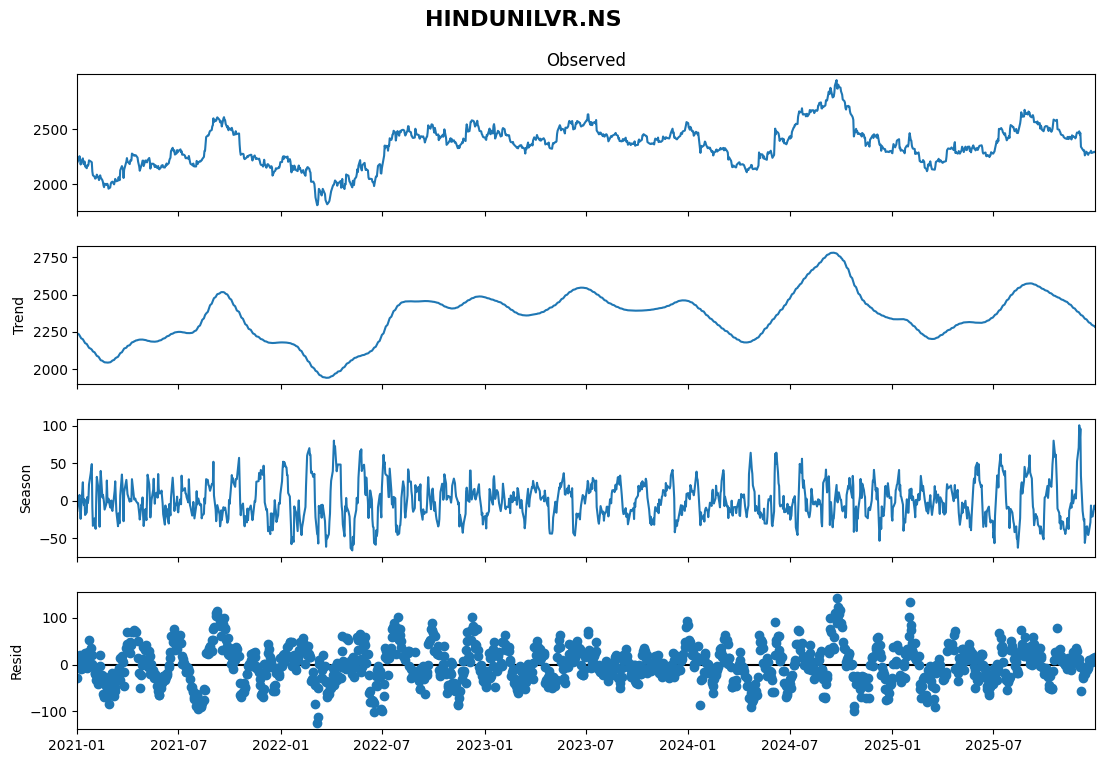

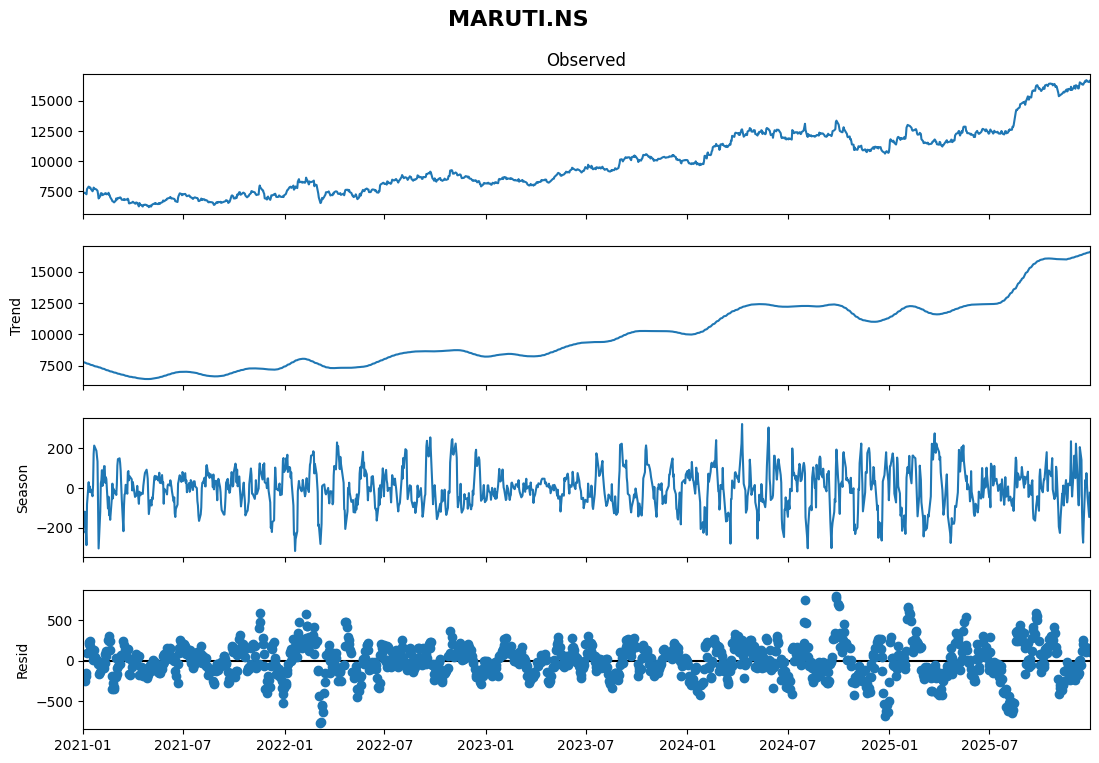

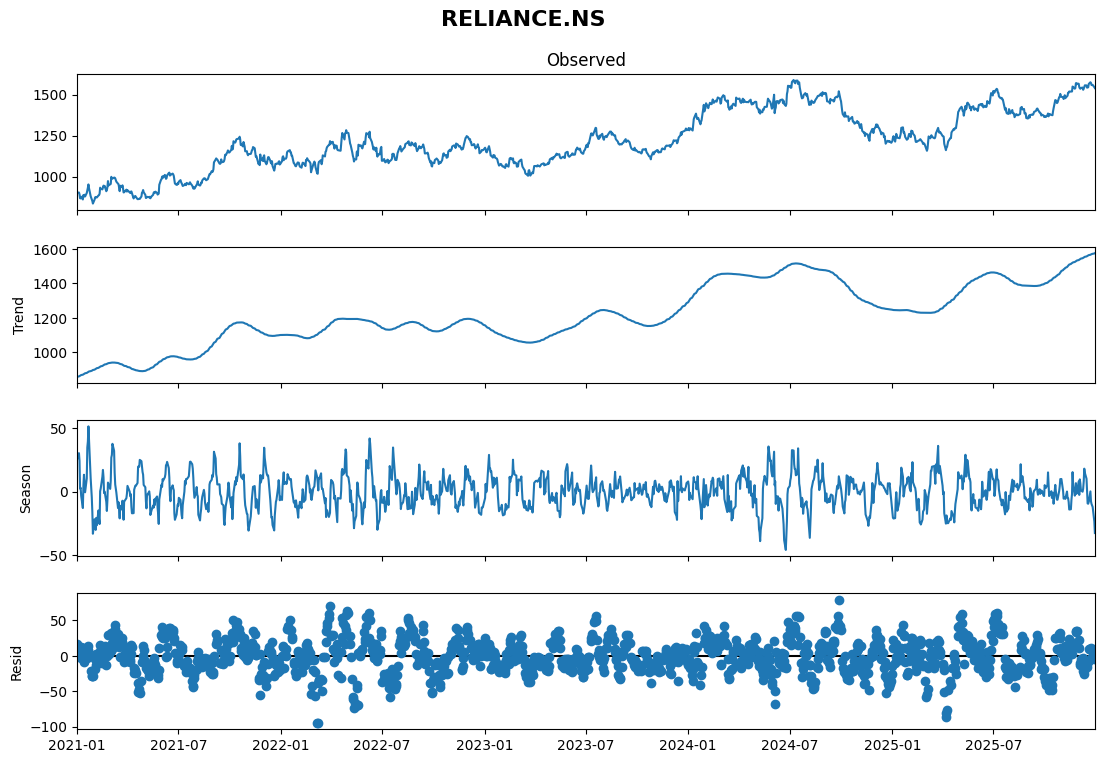

In [31]:
trend_analysis = {}

for stock, df in stock_data.items():

    stl = STL(
        df['Close'].dropna(),
        period=30
    )

    result = stl.fit()

    trend_analysis[stock] = result

    fig = result.plot()

    fig.set_size_inches(12, 8)

    fig.subplots_adjust(top=0.90)

    fig.suptitle(
        stock,
        fontsize=16,
        fontweight='bold'
    )

    fig.savefig(
        f'../outputs/plots/{stock}_stl.png',
        bbox_inches='tight'
    )

    plt.show()

# SECTION 6 — ARIMA MODELING

## Evaluation Metrics

In [32]:
def rmse(actual, predicted):

    return np.sqrt(
        mean_squared_error(actual, predicted)
    )


def directional_accuracy(actual, predicted):

    actual = np.array(actual).flatten()

    predicted = np.array(predicted).flatten()

    min_length = min(
        len(actual),
        len(predicted)
    )

    actual = actual[:min_length]

    predicted = predicted[:min_length]

    actual_direction = np.sign(
        np.diff(actual)
    )

    predicted_direction = np.sign(
        np.diff(predicted)
    )

    min_dir_length = min(
        len(actual_direction),
        len(predicted_direction)
    )

    actual_direction = actual_direction[
        :min_dir_length
    ]

    predicted_direction = predicted_direction[
        :min_dir_length
    ]

    return np.mean(
        actual_direction == predicted_direction
    ) * 100

## ARIMA Training and Forecasting

In [33]:
forecast_results = {}

model_metrics = []

for stock in STOCKS.keys():

    print(f'Processing {stock}')

    train = train_data[stock]['Close']

    test = test_data[stock]['Close']

    auto_model = auto_arima(
        train,
        seasonal=False,
        trace=False,
        suppress_warnings=True
    )

    order = auto_model.order

    model = ARIMA(
        train,
        order=order
    )

    fitted_model = model.fit()

    predictions = fitted_model.forecast(
        steps=len(test)
    )

    future_forecast = fitted_model.forecast(
        steps=5
    )

    mape_score = (
        mean_absolute_percentage_error(
            test,
            predictions
        ) * 100
    )

    rmse_score = rmse(
        test,
        predictions
    )

    da_score = directional_accuracy(
        test.values,
        predictions.values
    )

    model_metrics.append({
        'Stock': stock,
        'MAPE': mape_score,
        'RMSE': rmse_score,
        'Directional Accuracy': da_score,
        'ARIMA Order': order
    })

    forecast_results[stock] = {
        'Predictions': predictions,
        'Future Forecast': future_forecast,
        'Model': fitted_model
    }

Processing HDFCBANK.NS
Processing TCS.NS
Processing SUNPHARMA.NS
Processing HINDUNILVR.NS
Processing MARUTI.NS
Processing RELIANCE.NS


# SECTION 7 — FORECAST VISUALIZATION

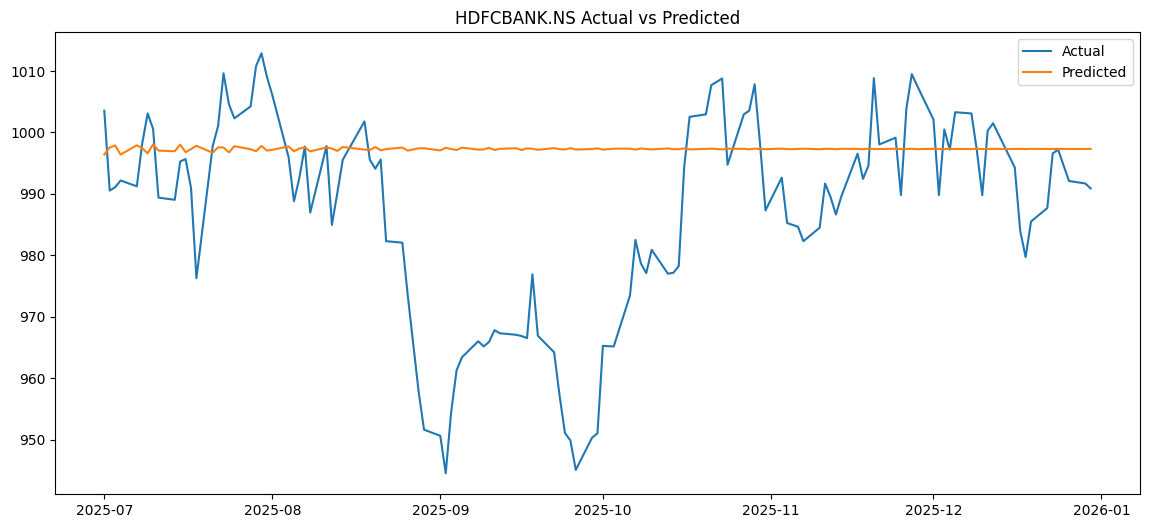

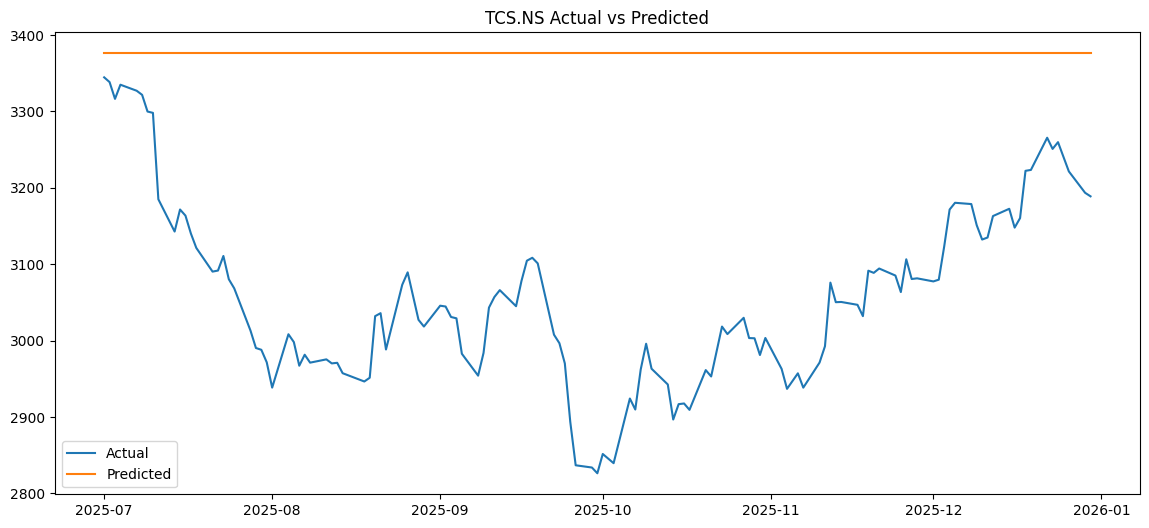

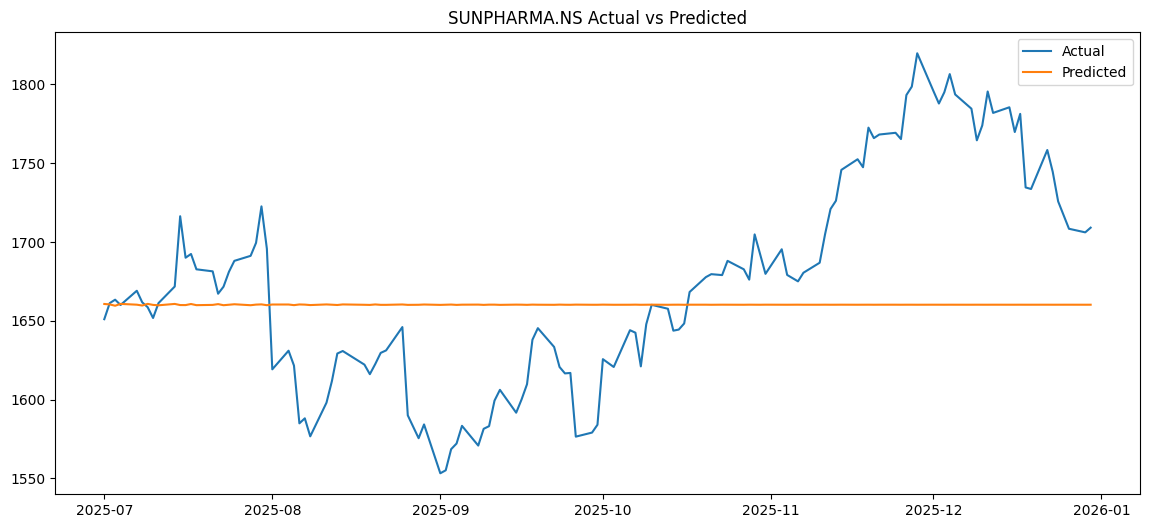

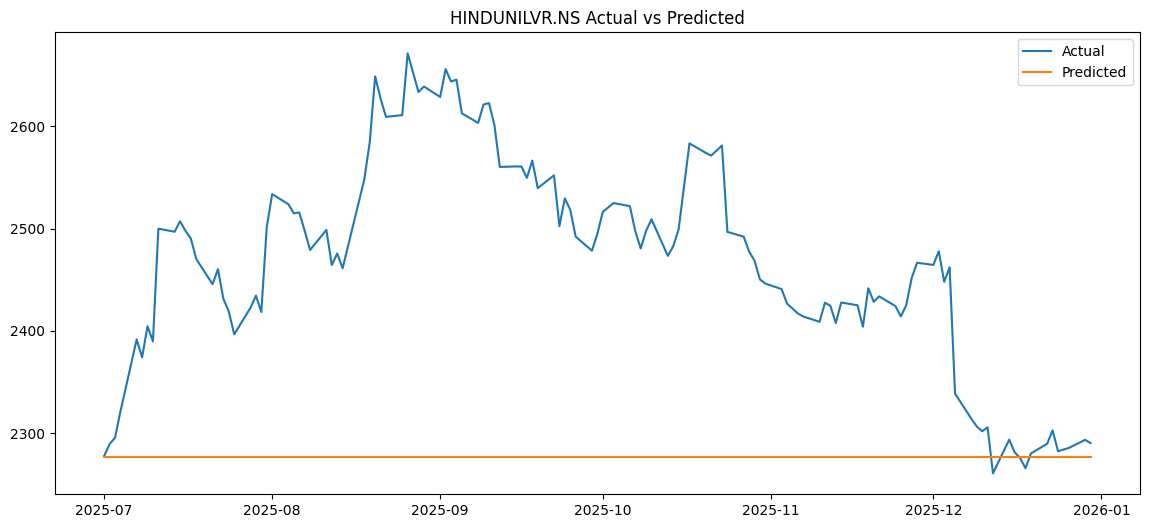

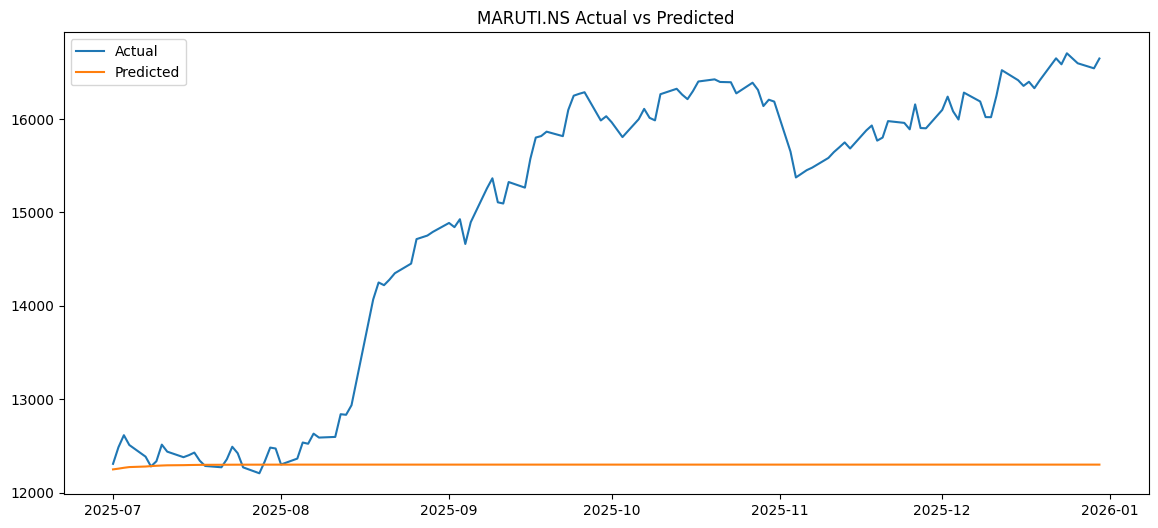

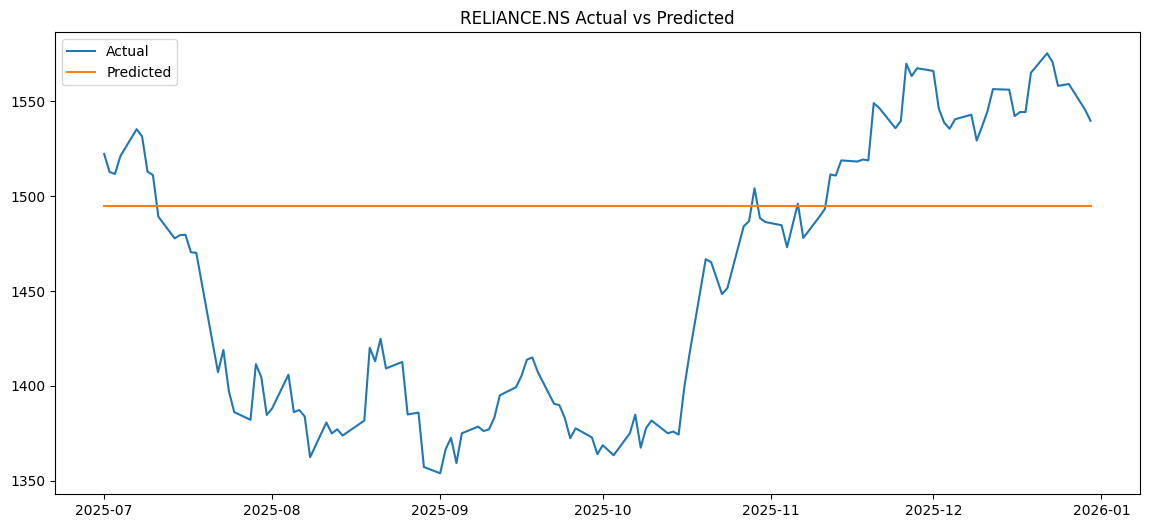

In [34]:
for stock in STOCKS.keys():

    plt.figure(figsize=(14, 6))

    plt.plot(
        test_data[stock].index,
        test_data[stock]['Close'],
        label='Actual'
    )

    plt.plot(
        test_data[stock].index,
        forecast_results[stock]['Predictions'],
        label='Predicted'
    )

    plt.title(f'{stock} Actual vs Predicted')

    plt.legend()

    plt.savefig(
        f'../outputs/plots/{stock}_forecast.png',
        bbox_inches='tight'
    )

    plt.show()

# SECTION 8 — VOLATILITY ANALYSIS

In [35]:
volatility_summary = {}

for stock, df in stock_data.items():

    df['Log_Returns'] = np.log(
        df['Close'] / df['Close'].shift(1)
    )

    df['Volatility'] = (
        df['Log_Returns']
        .rolling(30)
        .std()
    )

    volatility_summary[stock] = (
        df['Volatility'].mean()
    )

# SECTION 9 — CORRELATION ANALYSIS

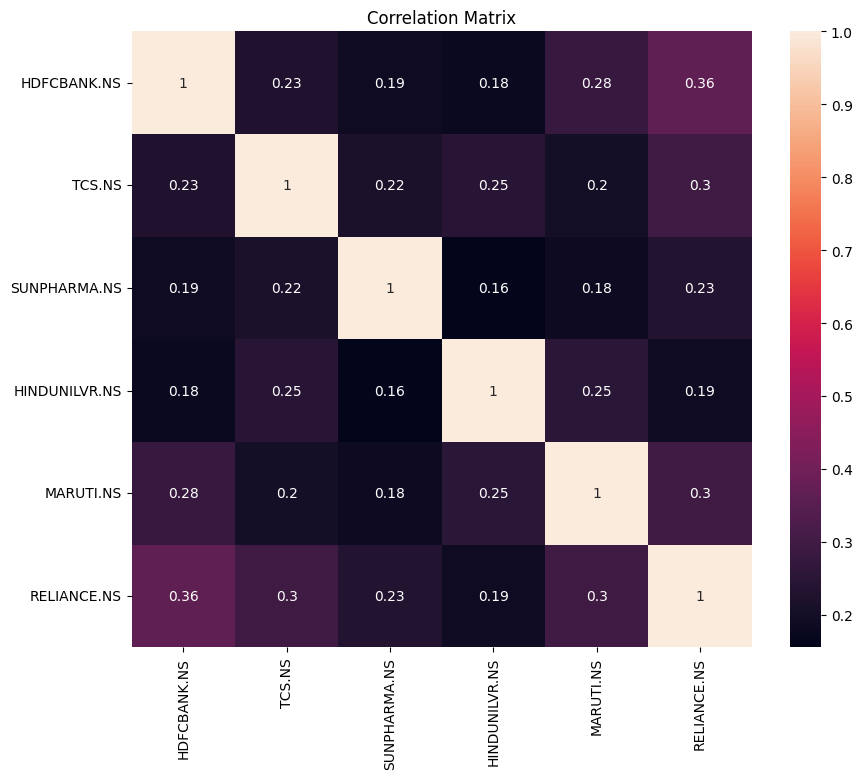

In [36]:
returns_df = pd.DataFrame()

for stock, df in stock_data.items():

    returns_df[stock] = (
        df['Close'].pct_change()
    )

correlation_matrix = returns_df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True
)

plt.title('Correlation Matrix')

plt.savefig(
    '../outputs/plots/correlation_heatmap.png',
    bbox_inches='tight'
)

plt.show()

# SECTION 10 — PORTFOLIO CONSTRUCTION

## Forecast Guided Allocation

In [37]:
expected_returns = {}

for stock in STOCKS.keys():

    current_price = (
    stock_data[stock]['Close']
    .iloc[-1]
    .item()
)

    predicted_price = (
    forecast_results[stock]
    ['Future Forecast']
    .iloc[-1]
    .item()
)
    expected_return = (
        (predicted_price - current_price)
        / current_price
    )

    expected_returns[stock] = expected_return

## Volatility Aware Weighting

In [38]:
inverse_volatility = {}

for stock in STOCKS.keys():

    inverse_volatility[stock] = (
        1 / volatility_summary[stock]
    )

vol_sum = sum(
    inverse_volatility.values()
)

weights = {}

for stock in STOCKS.keys():

    weights[stock] = (
        inverse_volatility[stock]
        / vol_sum
    )

## Portfolio Allocation Table

In [39]:
portfolio_table = []

for stock in STOCKS.keys():

    allocation = (
        weights[stock]
        * INITIAL_CAPITAL
    )

    portfolio_table.append({
        'Stock': stock,
        'Sector': STOCKS[stock],
        'Weight': round(
            weights[stock] * 100,
            2
        ),
        'Allocated Amount': round(
            allocation,
            2
        ),
        'Expected Return':
            expected_returns[stock]
    })

portfolio_df = pd.DataFrame(
    portfolio_table
)

portfolio_df

,Stock,Sector,Weight,Allocated Amount,Expected Return
0,HDFCBANK.NS,Banking,17.06,170569.08,0.007071
1,TCS.NS,IT,16.94,169364.69,0.058725
2,SUNPHARMA.NS,Pharma,17.07,170747.88,-0.028603
3,HINDUNILVR.NS,FMCG,17.65,176461.24,-0.005893
4,MARUTI.NS,Auto,15.56,155577.80,-0.262324
5,RELIANCE.NS,Energy,15.73,157279.31,-0.029335


# SECTION 11 — SAVE OUTPUTS

In [40]:
portfolio_df.to_csv(
    '../outputs/tables/portfolio_allocation.csv',
    index=False
)

metrics_df = pd.DataFrame(
    model_metrics
)

metrics_df.to_csv(
    '../outputs/tables/model_metrics.csv',
    index=False
)

# SECTION 12 — FUTURE FORECAST TABLE

In [41]:
forecast_table = []

for stock in STOCKS.keys():

    forecast = (
        forecast_results[stock]
        ['Future Forecast']
    )

    forecast_table.append({
        'Stock': stock,
        'Day_1_Prediction': forecast.iloc[0],
        'Day_2_Prediction': forecast.iloc[1]
    })

forecast_df = pd.DataFrame(
    forecast_table
)

forecast_df

forecast_df.to_csv(
    '../outputs/forecasts/forecast_table.csv',
    index=False
)

# SECTION 13 — USER INPUT REQUIRED AFTER TRADING

In [42]:
ACTUAL_RESULTS = {

    'HDFCBANK.NS': {
        'Day_1_Actual_Close': 169451.88,
        'Day_2_Actual_Close': 173115.84
    },

    'TCS.NS': {
        'Day_1_Actual_Close': 164065.50,
        'Day_2_Actual_Close': 165314.25
    },

    'SUNPHARMA.NS': {
        'Day_1_Actual_Close': 170128.62,
        'Day_2_Actual_Close': 171611.04
    },

    'HINDUNILVR.NS': {
        'Day_1_Actual_Close': 176404.63,
        'Day_2_Actual_Close': 175944.06
    },

    'MARUTI.NS': {
        'Day_1_Actual_Close': 153443.88,
        'Day_2_Actual_Close': 154813.92
    },

    'RELIANCE.NS': {
        'Day_1_Actual_Close': 156503.88,
        'Day_2_Actual_Close': 156603.33
    }
}

# SECTION 14 — PREDICTED VS ACTUAL COMPARISON

In [43]:
comparison_rows = []

for stock in STOCKS.keys():

    predicted_day_1 = (
        forecast_df.loc[
            forecast_df['Stock'] == stock,
            'Day_1_Prediction'
        ].values[0]
    )

    predicted_day_2 = (
        forecast_df.loc[
            forecast_df['Stock'] == stock,
            'Day_2_Prediction'
        ].values[0]
    )

    actual_day_1 = (
        ACTUAL_RESULTS[stock]
        ['Day_1_Actual_Close']
    )

    actual_day_2 = (
        ACTUAL_RESULTS[stock]
        ['Day_2_Actual_Close']
    )

    comparison_rows.append({
        'Stock': stock,
        'Predicted_Day_1': predicted_day_1,
        'Actual_Day_1': actual_day_1,
        'Predicted_Day_2': predicted_day_2,
        'Actual_Day_2': actual_day_2
    })

comparison_df = pd.DataFrame(
    comparison_rows
)

comparison_df

,Stock,Predicted_Day_1,Actual_Day_1,Predicted_Day_2,Actual_Day_2
0,HDFCBANK.NS,996.410552,169451.88,997.544402,173115.84
1,TCS.NS,3376.096191,164065.50,3376.096191,165314.25
2,SUNPHARMA.NS,1660.662912,170128.62,1660.386402,171611.04
3,HINDUNILVR.NS,2276.702881,176404.63,2276.702881,175944.06
4,MARUTI.NS,12249.374850,153443.88,12257.506207,154813.92
5,RELIANCE.NS,1494.630615,156503.88,1494.630615,156603.33


# SECTION 15 — FINAL REFLECTION INPUTS

In [44]:


EXECUTION_WINDOW = 'Wed 13 May ->   Thu 14 May'

TOTAL_PORTFOLIO_RETURN = -0.20

BEST_PERFORMING_STOCK = 'HDFCBANK.NS'

WORST_PERFORMING_STOCK = 'TCS.NS'

OBSERVATIONS = '''
The ARIMA-based portfolio demonstrated moderate stability under real market conditions. 
Although TCS and MARUTI generated significant negative returns during the observation window, positive contributions from HDFCBANK and RELIANCE helped reduce the overall portfolio loss.
The diversification and volatility-aware allocation strategy prevented major drawdowns, resulting in a relatively small final portfolio decline of 0.20%.
'''